## Predictive Model Development
Build a machine learning model that predicts whether a hotel booking will be cancelled, using baseline + XGBoost + AutoML to compare

1. Class Imbalance Handling
2. Baseline Model, logistic regression, random forest
3. XGBoost with Hyperparameter Tuning
4. AutoML with PyCaret
5. AutoML with AutoGluon
6. Model Evaluation (AUC, F1, Confusion Matrix, ROC)
7. Model saving

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, auc, roc_auc_score,
    roc_curve, f1_score, precision_score, recall_score, accuracy_score,
    ConfusionMatrixDisplay, RocCurveDisplay, average_precision_score,
    precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model  import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

# Additional imports for automl
from pycaret.classification import (
    setup, compare_models, pull,
    tune_model, blend_models, stack_models, predict_model
)
from autogluon.tabular import TabularPredictor

from datetime import datetime

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
print('Libraries loaded.')

Libraries loaded.


### Load & Prepare Features

Load the feature engineered data and the different feature sets to test on

In [14]:
SEED = 42
TARGET = "is_canceled"

df = pd.read_csv("./data/hotel_bookings_feature_engineered.csv")
print("Loaded:", df.shape)

Loaded: (87029, 67)


In [15]:
DROP_ALWAYS = [
    'reservation_status',       # leakage
    'reservation_status_date',  # leakage
    'arrival_date',             # redundant with year/month/day
    'arrival_weekday',          # redundant with is_weekend_arrival
    'lead_time_bucket',         # categorical bin of lead_time, keep original
    'country',                  # high cardinality, continent used instead
    'country_code_iso3',        # redundant with continent
    'agent',                    # ID column — high cardinality, no semantics
    'company',                  # ID column — high cardinality, no semantics
]

df_model = df.drop(columns=[c for c in DROP_ALWAYS if c in df.columns]).copy()

In [16]:
df_model.isnull().sum().sum()

0

In [17]:
# build feature-set dictionary
feature_sets_path = "./data/feature_sets/feature_sets.json"
if os.path.exists(feature_sets_path):
    with open(feature_sets_path, "r", encoding="utf-8") as f:
        feature_sets = json.load(f)
else:
    all_cols = [c for c in df_model.columns if c != TARGET]
    feature_sets = {"all_features": all_cols}

# keep only existing columns in current dataframe
for k, v in feature_sets.items():
    feature_sets[k] = [c for c in v if c in df_model.columns and c != TARGET]

print("Feature sets loaded:")
for k, v in feature_sets.items():
    print(f"{k}: {len(v)} features")

Feature sets loaded:
all_train_cols: 58 features
after_variance: 46 features
after_mi: 28 features
after_xgb: 27 features
after_corr: 22 features


In [18]:
# split before encoding

X_raw = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=SEED, stratify=y
)

In [19]:
# encode categoricals (fit on train only, transform test)
cat_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train_cat = pd.DataFrame(
    encoder.fit_transform(X_train_raw[cat_cols]),
    columns=cat_cols,
    index=X_train_raw.index
)
X_test_cat = pd.DataFrame(
    encoder.transform(X_test_raw[cat_cols]),
    columns=cat_cols,
    index=X_test_raw.index
)

X_train = pd.concat([X_train_raw[num_cols], X_train_cat], axis=1)
X_test = pd.concat([X_test_raw[num_cols], X_test_cat], axis=1)

print("Train/Test:", X_train.shape, X_test.shape)


Train/Test: (69623, 58) (17406, 58)


In [20]:
X_test.isna().sum().sum()

0

In [23]:
# save encoder fitted model for later use in inference pipeline
joblib.dump(encoder, "./models/ordinal_encoder.pkl")
print("Saved encoder: ./models/ordinal_encoder.pkl")


Saved encoder: ./models/ordinal_encoder.pkl


### Enhanced XGB + AutoML Search

Feature sets are: all features, after variance, after mutual information.
Run XGB on the 3 sets + more enhanced hyper parameter search.
Run automl on 3 sets + with and without balancing + run parameter tuning and ensemble models


In [21]:
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

In [22]:
# ensure we have three feature sets: all + 2 selected
feature_sets['all_features'] = [c for c in X_train.columns if c != TARGET]
ENHANCED_SET_NAMES = ['all_features', 'after_variance', 'after_mi']
ENHANCED_SET_NAMES = [s for s in ENHANCED_SET_NAMES if s in feature_sets]

for k in ENHANCED_SET_NAMES:
    feature_sets[k] = [c for c in feature_sets[k] if c in X_train.columns and c != TARGET]

print('Enhanced feature sets:')
for k in ENHANCED_SET_NAMES:
    print(f'  {k}: {len(feature_sets[k])} features')


Enhanced feature sets:
  all_features: 58 features
  after_variance: 46 features
  after_mi: 28 features


#### Baseline

In [43]:
# Baselines (RF/LR) on all_features + selected feature sets
# Saves same metric columns as XGB/AutoML:
# cv_accuracy_mean, cv_auc_mean, cv_pr_auc_mean, cv_f1_mean, cv_precision_mean, cv_recall_mean

baseline_results = []
for fs_name in ENHANCED_SET_NAMES:
    cols = feature_sets[fs_name]
    Xtr = X_train[cols]

    # RF no balancing
    rf_plain = RandomForestClassifier(
        n_estimators=300, random_state=SEED, n_jobs=-1, class_weight=None
    )
    scores = cross_validate(
        rf_plain, Xtr, y_train, cv=cv3, scoring={
            "accuracy": "accuracy",
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision",
            "f1": "f1",
            "precision": "precision",
            "recall": "recall"
        }, n_jobs=-1, error_score="raise"
    )
    baseline_results.append({
        "model_name": "RF",
        "feature_set": fs_name,
        "balanced": False,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_auc_mean": scores["test_roc_auc"].mean(),
        "cv_pr_auc_mean": scores["test_pr_auc"].mean(),
        "cv_f1_mean": scores["test_f1"].mean(),
        "cv_precision_mean": scores["test_precision"].mean(),
        "cv_recall_mean": scores["test_recall"].mean(),
        "source": "baseline"
    })

    # RF with balancing (SMOTE in CV pipeline)
    rf_smote = ImbPipeline([
        ("smote", SMOTE(random_state=SEED)),
        ("model", RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1))
    ])
    scores = cross_validate(
        rf_smote, Xtr, y_train, cv=cv3, scoring={
            "accuracy": "accuracy",
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision",
            "f1": "f1",
            "precision": "precision",
            "recall": "recall"
        }, n_jobs=-1, error_score="raise"
    )
    baseline_results.append({
        "model_name": "RF",
        "feature_set": fs_name,
        "balanced": True,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_auc_mean": scores["test_roc_auc"].mean(),
        "cv_pr_auc_mean": scores["test_pr_auc"].mean(),
        "cv_f1_mean": scores["test_f1"].mean(),
        "cv_precision_mean": scores["test_precision"].mean(),
        "cv_recall_mean": scores["test_recall"].mean(),
        "source": "baseline"
    })

    # LR no balancing
    lr_plain = SkPipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=SEED))
    ])
    scores = cross_validate(
        lr_plain, Xtr, y_train, cv=cv3, scoring={
            "accuracy": "accuracy",
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision",
            "f1": "f1",
            "precision": "precision",
            "recall": "recall"
        }, n_jobs=-1, error_score="raise"
    )
    baseline_results.append({
        "model_name": "LR",
        "feature_set": fs_name,
        "balanced": False,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_auc_mean": scores["test_roc_auc"].mean(),
        "cv_pr_auc_mean": scores["test_pr_auc"].mean(),
        "cv_f1_mean": scores["test_f1"].mean(),
        "cv_precision_mean": scores["test_precision"].mean(),
        "cv_recall_mean": scores["test_recall"].mean(),
        "source": "baseline"
    })

    # LR with balancing (SMOTE + scaler + LR)
    lr_smote = ImbPipeline([
        ("smote", SMOTE(random_state=SEED)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=SEED))
    ])
    scores = cross_validate(
        lr_smote, Xtr, y_train, cv=cv3, scoring={
            "accuracy": "accuracy",
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision",
            "f1": "f1",
            "precision": "precision",
            "recall": "recall"
        }, n_jobs=-1, error_score="raise"
    )
    baseline_results.append({
        "model_name": "LR",
        "feature_set": fs_name,
        "balanced": True,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_auc_mean": scores["test_roc_auc"].mean(),
        "cv_pr_auc_mean": scores["test_pr_auc"].mean(),
        "cv_f1_mean": scores["test_f1"].mean(),
        "cv_precision_mean": scores["test_precision"].mean(),
        "cv_recall_mean": scores["test_recall"].mean(),
        "source": "baseline"
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("cv_auc_mean", ascending=False).reset_index(drop=True)
display(baseline_df)


,model_name,feature_set,balanced,cv_accuracy_mean,cv_auc_mean,cv_pr_auc_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean,source
0,RF,after_variance,False,0.833518,0.887661,0.765604,0.661549,0.750920,0.591201,baseline
1,RF,all_features,False,0.832929,0.887235,0.764098,0.659351,0.751240,0.587495,baseline
2,RF,after_variance,True,0.831708,0.885920,0.758920,0.676312,0.718443,0.638850,baseline
3,RF,all_features,True,0.831722,0.885128,0.758216,0.675565,0.719608,0.636606,baseline
4,RF,after_mi,False,0.822975,0.877024,0.741388,0.648635,0.714900,0.593654,baseline
5,RF,after_mi,True,0.820620,0.875982,0.736811,0.664141,0.685187,0.644382,baseline
6,LR,all_features,False,0.788834,0.817109,0.647829,0.519178,0.695420,0.414227,baseline
7,LR,after_variance,False,0.788504,0.816282,0.646679,0.517460,0.695503,0.412035,baseline
8,LR,after_mi,False,0.788590,0.814960,0.644471,0.515103,0.698471,0.408016,baseline
9,LR,all_features,True,0.759849,0.806373,0.631208,0.579743,0.559195,0.601900,baseline


#### XGB

In [42]:
# Expanded XGB randomized search + threshold tuning + full CV metrics
xgb_enhanced_results = []
xgb_enhanced_estimators = {}

xgb_param_dist = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.02, 0.03, 0.05, 0.08, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [1, 2, 5, 10]
}

for fs_name in ENHANCED_SET_NAMES:
    cols = feature_sets[fs_name]
    Xtr_all = X_train[cols]

    for use_smote in [False, True]:
        if use_smote:
            base_xgb = XGBClassifier(random_state=SEED, eval_metric='auc', n_jobs=-1)
            estimator = ImbPipeline([
                ('smote', SMOTE(random_state=SEED)),
                ('xgb', base_xgb)
            ])
            search_space = {f'xgb__{k}': v for k, v in xgb_param_dist.items()}
            key = f'XGB_SMOTE__{fs_name}'
        else:
            neg = (y_train == 0).sum()
            pos = (y_train == 1).sum()
            base_xgb = XGBClassifier(
                random_state=SEED,
                eval_metric='auc',
                n_jobs=-1,
                scale_pos_weight=neg / pos
            )
            estimator = base_xgb
            search_space = xgb_param_dist
            key = f'XGB__{fs_name}'

        # tune by AUC
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=search_space,
            n_iter=30,
            scoring='roc_auc',
            cv=cv3,
            random_state=SEED,
            n_jobs=-1,
            verbose=0
        )
        search.fit(Xtr_all, y_train)

        best_estimator = clone(search.best_estimator_)

        # full CV metrics on tuned model
        cv_scores = cross_validate(
            best_estimator,
            Xtr_all, y_train,
            cv=cv3,
            scoring={
                "accuracy": "accuracy",
                "roc_auc": "roc_auc",
                "pr_auc": "average_precision",
                "f1": "f1",
                "precision": "precision",
                "recall": "recall"
            },
            n_jobs=-1,
            error_score="raise"
        )

        # threshold tuning on train-validation split
        X_fit, X_thr, y_fit, y_thr = train_test_split(
            Xtr_all, y_train, test_size=0.2, random_state=SEED, stratify=y_train
        )

        thr_model = clone(search.best_estimator_)
        thr_model.fit(X_fit, y_fit)
        thr_probs = thr_model.predict_proba(X_thr)[:, 1]

        candidate_thresholds = np.linspace(0.20, 0.80, 61)
        best_thr, best_thr_f1 = 0.5, -1
        for thr in candidate_thresholds:
            pred = (thr_probs >= thr).astype(int)
            f1 = f1_score(y_thr, pred)
            if f1 > best_thr_f1:
                best_thr_f1 = f1
                best_thr = thr

        # fit final tuned model on full train for later test/inference
        final_est = clone(search.best_estimator_)
        final_est.fit(Xtr_all, y_train)
        xgb_enhanced_estimators[key] = {
            'estimator': final_est,
            'threshold': float(best_thr)
        }

        xgb_enhanced_results.append({
            'model_name': 'XGB',
            'feature_set': fs_name,
            'balanced': use_smote,
            'cv_accuracy_mean': float(cv_scores['test_accuracy'].mean()),
            'cv_auc_mean': float(cv_scores['test_roc_auc'].mean()),
            'cv_pr_auc_mean': float(cv_scores['test_pr_auc'].mean()),
            'cv_f1_mean': float(cv_scores['test_f1'].mean()),
            'cv_precision_mean': float(cv_scores['test_precision'].mean()),
            'cv_recall_mean': float(cv_scores['test_recall'].mean()),
            'best_params': search.best_params_,
            'tuned_threshold': float(best_thr),
            'thr_val_f1': float(best_thr_f1),
            'key': key,
            'source': 'xgb'
        })

xgb_enhanced_df = pd.DataFrame(xgb_enhanced_results).sort_values('cv_auc_mean', ascending=False)
display(xgb_enhanced_df)


,model_name,feature_set,balanced,cv_accuracy_mean,cv_auc_mean,cv_pr_auc_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean,best_params,tuned_threshold,thr_val_f1,key,source
0,XGB,all_features,False,0.816885,0.900294,0.781921,0.708548,0.630430,0.808778,"{'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha...",0.61,0.719849,XGB__all_features,xgb
2,XGB,after_variance,False,0.811542,0.900078,0.780334,0.705896,0.618669,0.821773,"{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha...",0.60,0.721591,XGB__after_variance,xgb
1,XGB,all_features,True,0.837669,0.898880,0.780672,0.691304,0.725176,0.660456,"{'xgb__subsample': 0.9, 'xgb__reg_lambda': 1, ...",0.41,0.718582,XGB_SMOTE__all_features,xgb
3,XGB,after_variance,True,0.837554,0.898733,0.780200,0.691166,0.724809,0.660508,"{'xgb__subsample': 0.9, 'xgb__reg_lambda': 1, ...",0.42,0.718329,XGB_SMOTE__after_variance,xgb
4,XGB,after_mi,False,0.794608,0.890898,0.761569,0.687055,0.591590,0.819268,"{'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha...",0.59,0.698994,XGB__after_mi,xgb
5,XGB,after_mi,True,0.826164,0.888286,0.757594,0.679862,0.689217,0.670790,"{'xgb__subsample': 0.9, 'xgb__reg_lambda': 2, ...",0.38,0.696809,XGB_SMOTE__after_mi,xgb


#### AutoML Pycaret

In [41]:
# AutoML loop across 3 feature sets x balanced/unbalanced + tuning + blend/stack
# Saves: Accuracy, AUC, PR_AUC, F1, Recall, Precision

from pycaret.classification import (
    setup, compare_models, pull,
    tune_model, blend_models, stack_models, add_metric
)
from sklearn.metrics import average_precision_score

automl_loop_records = []
automl_models = {}

def _safe_metric_extract(df_pull):
    row = df_pull.iloc[0] if len(df_pull) else pd.Series(dtype=float)
    return {
        "Accuracy": float(row.get("Accuracy", np.nan)),
        "AUC": float(row.get("AUC", np.nan)),
        "PR_AUC": float(row.get("PR_AUC", row.get("PR-AUC", np.nan))),
        "F1": float(row.get("F1", np.nan)),
        "Recall": float(row.get("Recall", np.nan)),
        "Prec.": float(row.get("Prec.", np.nan)),
    }

for fs_name in ENHANCED_SET_NAMES:
    cols = feature_sets[fs_name]
    df_py = X_train[cols].copy()
    df_py[TARGET] = y_train.values

    for use_balance in [False, True]:
        run_tag = f'{fs_name}__{"bal" if use_balance else "unbal"}'
        print(f"AutoML run: {run_tag}")

        exp = setup(
            data=df_py,
            target=TARGET,
            session_id=SEED,
            fold=3,
            fix_imbalance=use_balance,
            verbose=False,
            html=False
        )

        # Add PR-AUC metric (probability-based)
        add_metric(
            id="pr_auc",
            name="PR_AUC",
            score_func=average_precision_score,
            target="pred_proba",
            greater_is_better=True
        )

        top3 = compare_models(sort="AUC", n_select=3, fold=3, verbose=False)
        cmp_tbl = pull().copy()

        # Optional: keep compare table rows too
        if len(cmp_tbl):
            for _, r in cmp_tbl.iterrows():
                automl_loop_records.append({
                    "model_name": f"pycaret_compare_{r.get('Model', 'unknown')}",
                    "feature_set": fs_name,
                    "balanced": use_balance,
                    "cv_accuracy_mean": float(r.get("Accuracy", np.nan)),
                    "cv_auc_mean": float(r.get("AUC", np.nan)),
                    "cv_pr_auc_mean": float(r.get("PR_AUC", r.get("PR-AUC", np.nan))),
                    "cv_f1_mean": float(r.get("F1", np.nan)),
                    "cv_recall_mean": float(r.get("Recall", np.nan)),
                    "cv_precision_mean": float(r.get("Prec.", np.nan)),
                    "source": "pycaret_compare"
                })

        # Normalize top3 into list
        top3_list = top3 if isinstance(top3, list) else [top3]

        tuned_models = []
        for idx, m in enumerate(top3_list[:2], start=1):
            tm = tune_model(m, optimize="AUC", fold=3, choose_better=True, verbose=False)
            tune_tbl = pull().copy()
            metrics = _safe_metric_extract(tune_tbl)
            tuned_models.append(tm)

            automl_loop_records.append({
                "model_name": f"pycaret_tuned_{idx}",
                "feature_set": fs_name,
                "balanced": use_balance,
                "cv_accuracy_mean": metrics["Accuracy"],
                "cv_auc_mean": metrics["AUC"],
                "cv_pr_auc_mean": metrics["PR_AUC"],
                "cv_f1_mean": metrics["F1"],
                "cv_recall_mean": metrics["Recall"],
                "cv_precision_mean": metrics["Prec."],
                "source": "pycaret_tuned"
            })
            automl_models[f"tuned_{idx}__{run_tag}"] = tm

        if len(tuned_models) >= 2:
            bm = blend_models(estimator_list=tuned_models, optimize="AUC", fold=3, verbose=False)
            blend_tbl = pull().copy()
            bm_metrics = _safe_metric_extract(blend_tbl)
            automl_loop_records.append({
                "model_name": "pycaret_blend",
                "feature_set": fs_name,
                "balanced": use_balance,
                "cv_accuracy_mean": bm_metrics["Accuracy"],
                "cv_auc_mean": bm_metrics["AUC"],
                "cv_pr_auc_mean": bm_metrics["PR_AUC"],
                "cv_f1_mean": bm_metrics["F1"],
                "cv_recall_mean": bm_metrics["Recall"],
                "cv_precision_mean": bm_metrics["Prec."],
                "source": "pycaret_blend"
            })
            automl_models[f"blend__{run_tag}"] = bm

            sm = stack_models(estimator_list=tuned_models, optimize="AUC", fold=3, verbose=False)
            stack_tbl = pull().copy()
            sm_metrics = _safe_metric_extract(stack_tbl)
            automl_loop_records.append({
                "model_name": "pycaret_stack",
                "feature_set": fs_name,
                "balanced": use_balance,
                "cv_accuracy_mean": sm_metrics["Accuracy"],
                "cv_auc_mean": sm_metrics["AUC"],
                "cv_pr_auc_mean": sm_metrics["PR_AUC"],
                "cv_f1_mean": sm_metrics["F1"],
                "cv_recall_mean": sm_metrics["Recall"],
                "cv_precision_mean": sm_metrics["Prec."],
                "source": "pycaret_stack"
            })
            automl_models[f"stack__{run_tag}"] = sm

automl_loop_df = pd.DataFrame(automl_loop_records).sort_values("cv_auc_mean", ascending=False)
display(automl_loop_df.head(30))


AutoML run: all_features__unbal
AutoML run: all_features__bal
AutoML run: after_variance__unbal
AutoML run: after_variance__bal
AutoML run: after_mi__unbal
AutoML run: after_mi__bal


,model_name,feature_set,balanced,cv_accuracy_mean,cv_auc_mean,cv_pr_auc_mean,cv_f1_mean,cv_recall_mean,cv_precision_mean,source
18,pycaret_stack,all_features,False,0.8329,0.8928,0.7682,0.6732,0.6254,0.7289,pycaret_stack
56,pycaret_stack,after_variance,False,0.8334,0.8927,0.7684,0.6738,0.6254,0.7304,pycaret_stack
0,pycaret_compare_Light Gradient Boosting Machine,all_features,False,0.8309,0.8926,0.7659,0.6688,0.6204,0.7254,pycaret_compare
17,pycaret_blend,all_features,False,0.8321,0.8926,0.7680,0.6720,0.6247,0.7270,pycaret_blend
55,pycaret_blend,after_variance,False,0.8336,0.8926,0.7683,0.6753,0.6287,0.7294,pycaret_blend
38,pycaret_compare_Light Gradient Boosting Machine,after_variance,False,0.8316,0.8926,0.7655,0.6695,0.6198,0.7279,pycaret_compare
37,pycaret_stack,all_features,True,0.8296,0.8920,0.7661,0.6899,0.6887,0.6911,pycaret_stack
36,pycaret_blend,all_features,True,0.8348,0.8920,0.7662,0.6831,0.6471,0.7234,pycaret_blend
75,pycaret_stack,after_variance,True,0.8313,0.8919,0.7662,0.6925,0.6900,0.6950,pycaret_stack
74,pycaret_blend,after_variance,True,0.8321,0.8919,0.7663,0.6769,0.6390,0.7196,pycaret_blend


#### Comparison and evaluation on test set

In [ ]:
# Consolidated comparison table (baseline + enhanced XGB + AutoML tuned/ensembled)
# Keep identical metric columns across all sources

metric_cols = [
    'cv_accuracy_mean',
    'cv_auc_mean',
    'cv_pr_auc_mean',
    'cv_f1_mean',
    'cv_precision_mean',
    'cv_recall_mean'
]

# baseline
baseline_cmp = baseline_df[
    ['model_name', 'feature_set', 'balanced'] + [c for c in metric_cols if c in baseline_df.columns]
].copy()
for c in metric_cols:
    if c not in baseline_cmp.columns:
        baseline_cmp[c] = np.nan
baseline_cmp['source'] = 'baseline'

# xgb
xgb_cmp = xgb_enhanced_df[
    ['model_name', 'feature_set', 'balanced'] + [c for c in metric_cols if c in xgb_enhanced_df.columns]
].copy()
for c in metric_cols:
    if c not in xgb_cmp.columns:
        xgb_cmp[c] = np.nan
xgb_cmp['source'] = 'xgb'

# automl
automl_cmp = automl_loop_df[
    ['model_name', 'feature_set', 'balanced'] + [c for c in metric_cols if c in automl_loop_df.columns]
].copy()
for c in metric_cols:
    if c not in automl_cmp.columns:
        automl_cmp[c] = np.nan
automl_cmp['source'] = automl_loop_df['source'].values if 'source' in automl_loop_df.columns else 'automl'

# combine
comparison_df = pd.concat([baseline_cmp, xgb_cmp, automl_cmp], ignore_index=True)
comparison_df = comparison_df[
    ['model_name', 'feature_set', 'balanced'] + metric_cols + ['source']
].sort_values('cv_auc_mean', ascending=False).reset_index(drop=True)

display(comparison_df.head(25))


,model_name,feature_set,balanced,cv_accuracy_mean,cv_auc_mean,cv_pr_auc_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean,source
0,XGB,all_features,False,0.816885,0.900294,0.781921,0.708548,0.630430,0.808778,xgb
1,XGB,after_variance,False,0.811542,0.900078,0.780334,0.705896,0.618669,0.821773,xgb
2,XGB,all_features,True,0.837669,0.898880,0.780672,0.691304,0.725176,0.660456,xgb
3,XGB,after_variance,True,0.837554,0.898733,0.780200,0.691166,0.724809,0.660508,xgb
4,pycaret_stack,all_features,False,0.832900,0.892800,0.768200,0.673200,0.728900,0.625400,pycaret_stack
5,pycaret_stack,after_variance,False,0.833400,0.892700,0.768400,0.673800,0.730400,0.625400,pycaret_stack
6,pycaret_compare_Light Gradient Boosting Machine,after_variance,False,0.831600,0.892600,0.765500,0.669500,0.727900,0.619800,pycaret_compare
7,pycaret_blend,after_variance,False,0.833600,0.892600,0.768300,0.675300,0.729400,0.628700,pycaret_blend
8,pycaret_blend,all_features,False,0.832100,0.892600,0.768000,0.672000,0.727000,0.624700,pycaret_blend
9,pycaret_compare_Light Gradient Boosting Machine,all_features,False,0.830900,0.892600,0.765900,0.668800,0.725400,0.620400,pycaret_compare


In [ ]:
# Evaluate top-3 overall on untouched test set (baseline + XGB + PyCaret + AutoGluon)
from sklearn.base import clone

def _get_pos_proba_ag(proba_df):
    if 1 in proba_df.columns:
        return proba_df[1].values
    if "1" in proba_df.columns:
        return proba_df["1"].values
    return proba_df.iloc[:, 1].values

def _eval_with_threshold_from_proba(yte, proba, threshold=0.5):
    yhat = (proba >= threshold).astype(int)
    return {
        "test_accuracy": (yhat == yte).mean(),
        "test_auc": roc_auc_score(yte, proba),
        "test_pr_auc": average_precision_score(yte, proba),
        "test_f1": f1_score(yte, yhat),
        "test_precision": precision_score(yte, yhat),
        "test_recall": recall_score(yte, yhat),
    }

top3_overall = comparison_df.head(3).copy()
display(top3_overall)

enhanced_test_rows = []
enhanced_saved_estimators = {}

for _, row in top3_overall.iterrows():
    mname = row["model_name"]
    fs_name = row["feature_set"]
    use_bal = bool(row["balanced"])
    src = row["source"]
    cols = feature_sets[fs_name]

    Xtr = X_train[cols]
    Xte = X_test[cols]
    threshold = 0.5

    # baseline
    if src == "baseline":
        if mname == "RF":
            if use_bal:
                est = ImbPipeline([
                    ("smote", SMOTE(random_state=SEED)),
                    ("model", RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1))
                ])
            else:
                est = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
        elif mname == "LR":
            if use_bal:
                est = ImbPipeline([
                    ("smote", SMOTE(random_state=SEED)),
                    ("scaler", StandardScaler()),
                    ("model", LogisticRegression(max_iter=2000, random_state=SEED))
                ])
            else:
                est = SkPipeline([
                    ("scaler", StandardScaler()),
                    ("model", LogisticRegression(max_iter=2000, random_state=SEED))
                ])
        else:
            continue

        est.fit(Xtr, y_train)
        proba = est.predict_proba(Xte)[:, 1]

    # xgb
    elif src == "xgb":
        key = ("XGB_SMOTE__" if use_bal else "XGB__") + fs_name
        est = clone(xgb_enhanced_estimators[key]["estimator"])
        threshold = float(xgb_enhanced_estimators[key].get("threshold", 0.5))
        est.fit(Xtr, y_train)
        proba = est.predict_proba(Xte)[:, 1]

    # pycaret automl
    else:
        run_tag = f"{fs_name}__{'bal' if use_bal else 'unbal'}"
        if "stack" in mname:
            key = f"stack__{run_tag}"
        elif "blend" in mname:
            key = f"blend__{run_tag}"
        elif mname.endswith("_2"):
            key = f"tuned_2__{run_tag}"
        else:
            key = f"tuned_1__{run_tag}"

        if key not in automl_models:
            continue

        est = automl_models[key]
        proba = est.predict_proba(Xte)[:, 1]

    metrics = _eval_with_threshold_from_proba(y_test, proba, threshold=threshold)

    rec = {
        "model_name": mname,
        "feature_set": fs_name,
        "balanced": use_bal,
        "source": src,
        "threshold": threshold,
        **metrics
    }
    enhanced_test_rows.append(rec)

    save_key = f"{mname}_{fs_name}_{'bal' if use_bal else 'unbal'}_{src}"
    enhanced_saved_estimators[save_key] = est

enhanced_test_df = pd.DataFrame(enhanced_test_rows).sort_values("test_auc", ascending=False)
display(enhanced_test_df)


,model_name,feature_set,balanced,cv_accuracy_mean,cv_auc_mean,cv_pr_auc_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean,source
0,XGB,all_features,False,0.816885,0.900294,0.781921,0.708548,0.630430,0.808778,xgb
1,XGB,after_variance,False,0.811542,0.900078,0.780334,0.705896,0.618669,0.821773,xgb
2,XGB,all_features,True,0.837669,0.898880,0.780672,0.691304,0.725176,0.660456,xgb


,model_name,feature_set,balanced,source,threshold,test_accuracy,test_auc,test_pr_auc,test_f1,test_precision,test_recall
0,XGB,all_features,False,xgb,0.61,0.839481,0.905178,0.797355,0.720935,0.691115,0.753445
1,XGB,after_variance,False,xgb,0.60,0.836780,0.905068,0.797624,0.721279,0.680363,0.767432
2,XGB,all_features,True,xgb,0.41,0.837585,0.904393,0.798308,0.719237,0.685925,0.755950


#### Visualizations

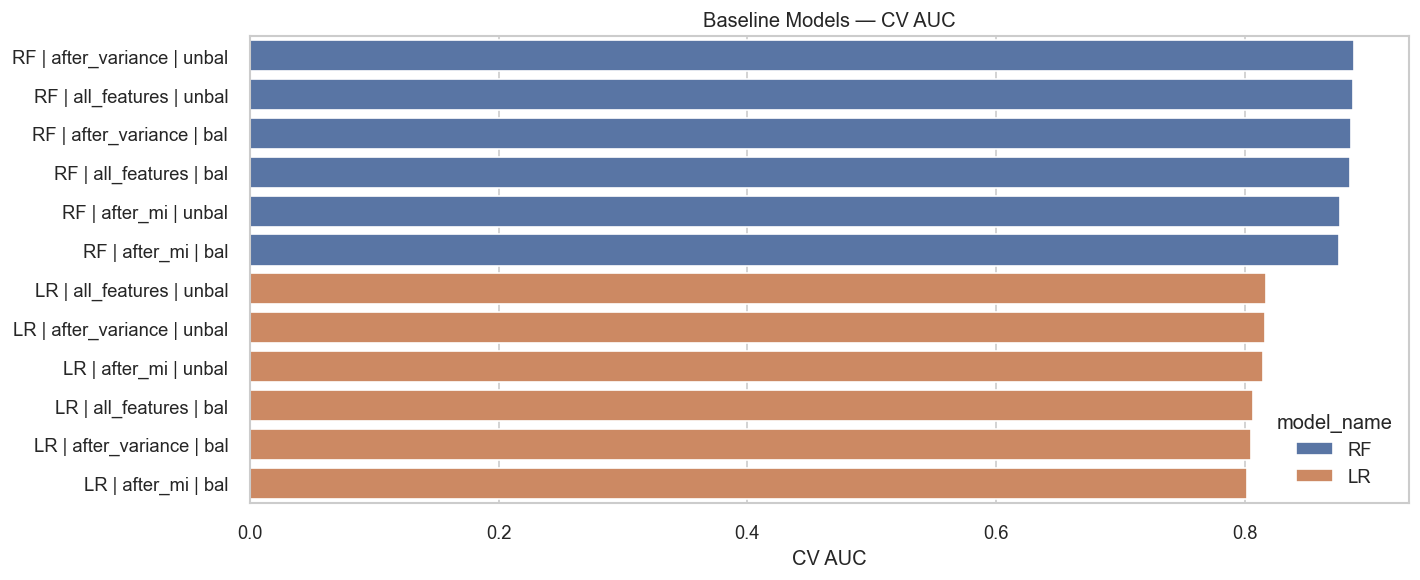

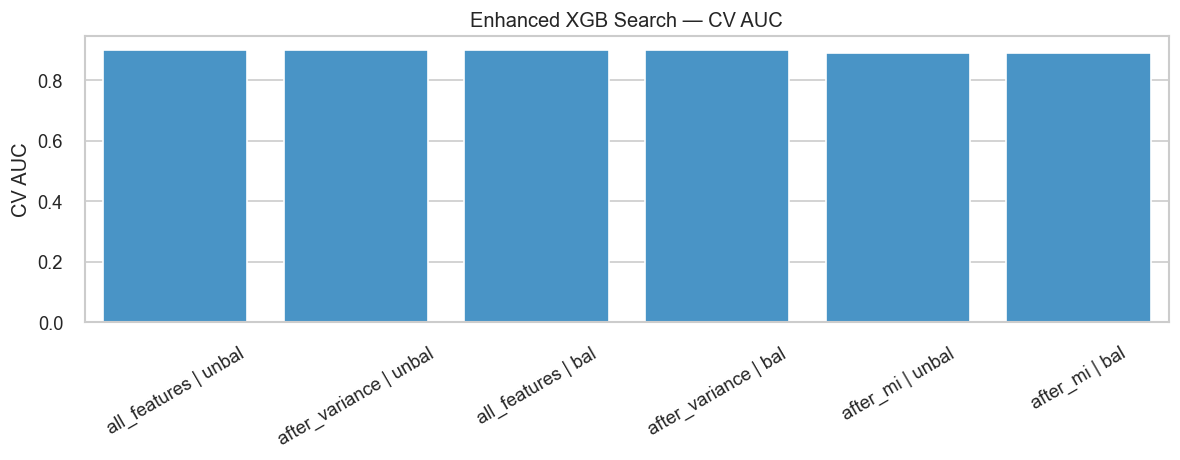

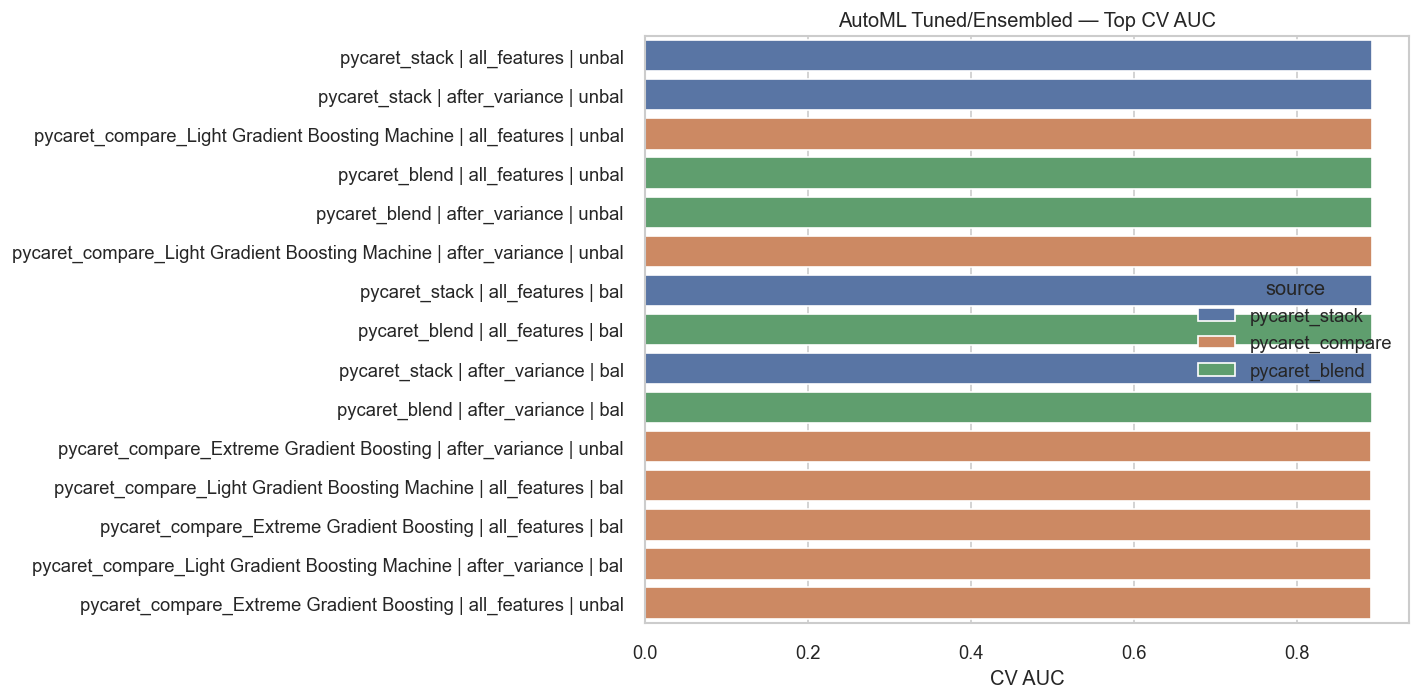

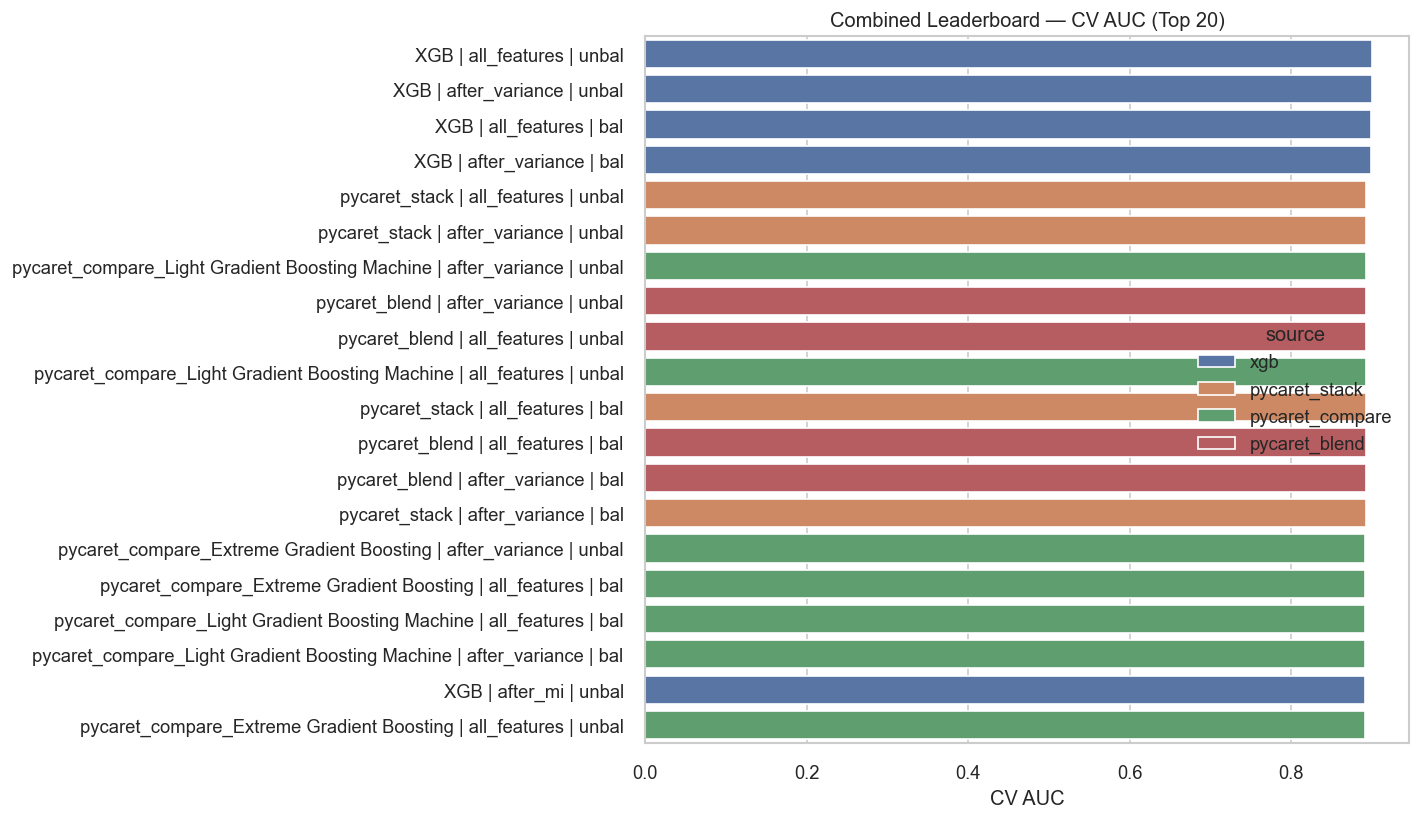

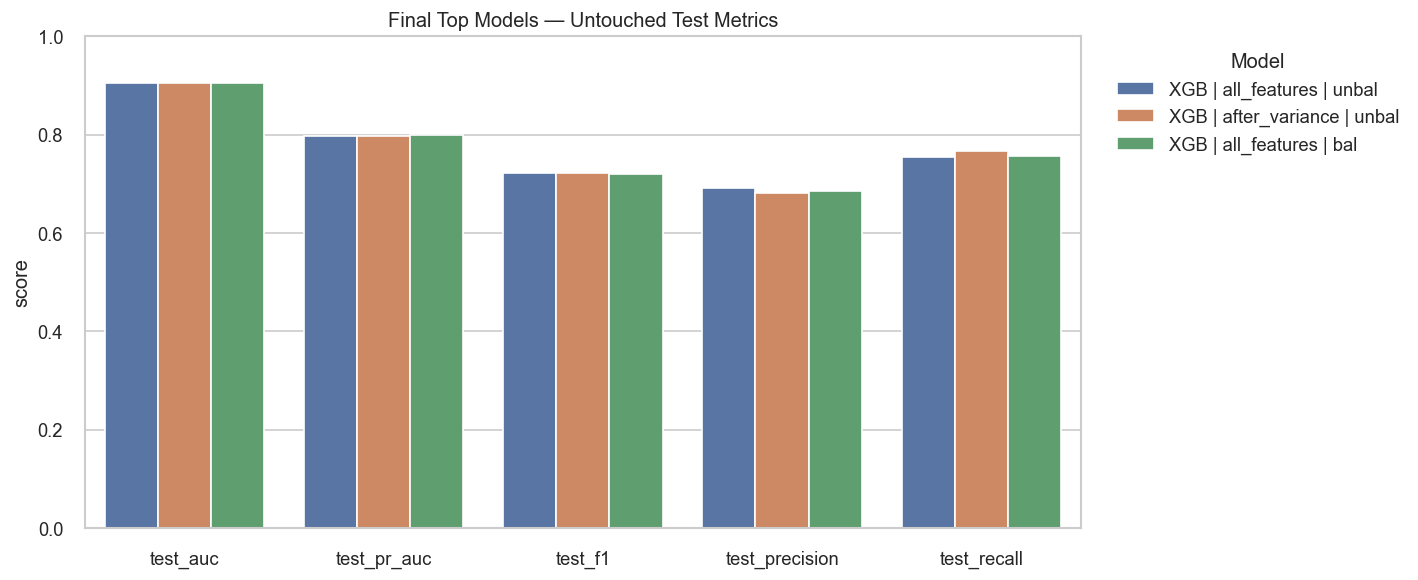

In [48]:
# Visualizations: enhanced pipeline + baseline
import os
sns.set_theme(style='whitegrid', font_scale=1.0)
os.makedirs('plots/enhanced', exist_ok=True)

# 0) Baseline CV AUC (added)
if 'baseline_df' in globals() and len(baseline_df) > 0:
    b = baseline_df.copy()
    b['label'] = b['model_name'] + ' | ' + b['feature_set'] + ' | ' + b['balanced'].map({True:'bal', False:'unbal'})
    b = b.sort_values('cv_auc_mean', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=b, y='label', x='cv_auc_mean', hue='model_name', ax=ax)
    ax.set_title('Baseline Models — CV AUC')
    ax.set_xlabel('CV AUC')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('plots/enhanced/00_baseline_cv_auc.png', bbox_inches='tight')
    plt.show()

# 1) Enhanced XGB CV AUC
if 'xgb_enhanced_df' in globals() and len(xgb_enhanced_df) > 0:
    xg = xgb_enhanced_df.copy()
    xg['label'] = xg['feature_set'] + ' | ' + xg['balanced'].map({True:'bal', False:'unbal'})
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=xg, x='label', y='cv_auc_mean', color='#3498DB', ax=ax)
    ax.set_title('Enhanced XGB Search — CV AUC')
    ax.set_xlabel('')
    ax.set_ylabel('CV AUC')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig('plots/enhanced/01_xgb_enhanced_cv_auc.png', bbox_inches='tight')
    plt.show()

# 2) AutoML runs CV AUC
if 'automl_loop_df' in globals() and len(automl_loop_df) > 0:
    a = automl_loop_df.copy().sort_values('cv_auc_mean', ascending=False).head(15)
    a['label'] = a['model_name'] + ' | ' + a['feature_set'] + ' | ' + a['balanced'].map({True:'bal', False:'unbal'})
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=a, y='label', x='cv_auc_mean', hue='source', ax=ax)
    ax.set_title('AutoML Tuned/Ensembled — Top CV AUC')
    ax.set_xlabel('CV AUC')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('plots/enhanced/02_automl_top_cv_auc.png', bbox_inches='tight')
    plt.show()

# 3) Combined top leaderboard
if 'comparison_df' in globals() and len(comparison_df) > 0:
    c = comparison_df.copy().sort_values('cv_auc_mean', ascending=False).head(20)
    c['label'] = c['model_name'] + ' | ' + c['feature_set'] + ' | ' + c['balanced'].map({True:'bal', False:'unbal'})
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(data=c, y='label', x='cv_auc_mean', hue='source', ax=ax)
    ax.set_title('Combined Leaderboard — CV AUC (Top 20)')
    ax.set_xlabel('CV AUC')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('plots/enhanced/03_combined_cv_leaderboard.png', bbox_inches='tight')
    plt.show()

# 4) Final top models test metrics
if 'enhanced_test_df' in globals() and len(enhanced_test_df) > 0:
    t = enhanced_test_df.copy()
    t['label'] = t['model_name'] + ' | ' + t['feature_set'] + ' | ' + t['balanced'].map({True:'bal', False:'unbal'})

    melt = t.melt(
        id_vars=['label'],
        value_vars=['test_auc','test_pr_auc','test_f1','test_precision','test_recall'],
        var_name='metric', value_name='score'
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=melt, x='metric', y='score', hue='label', ax=ax)
    ax.set_title('Final Top Models — Untouched Test Metrics')
    ax.set_xlabel('')
    ax.set_ylim(0, 1)
    ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('plots/enhanced/04_final_test_metrics.png', bbox_inches='tight')
    plt.show()


,model_name,feature_set,balanced,source,threshold,test_accuracy,test_auc,test_pr_auc,test_f1,test_precision,test_recall
0,XGB,all_features,False,xgb,0.61,0.839481,0.905178,0.797355,0.720935,0.691115,0.753445
1,XGB,after_variance,False,xgb,0.60,0.836780,0.905068,0.797624,0.721279,0.680363,0.767432
2,XGB,all_features,True,xgb,0.41,0.837585,0.904393,0.798308,0.719237,0.685925,0.755950


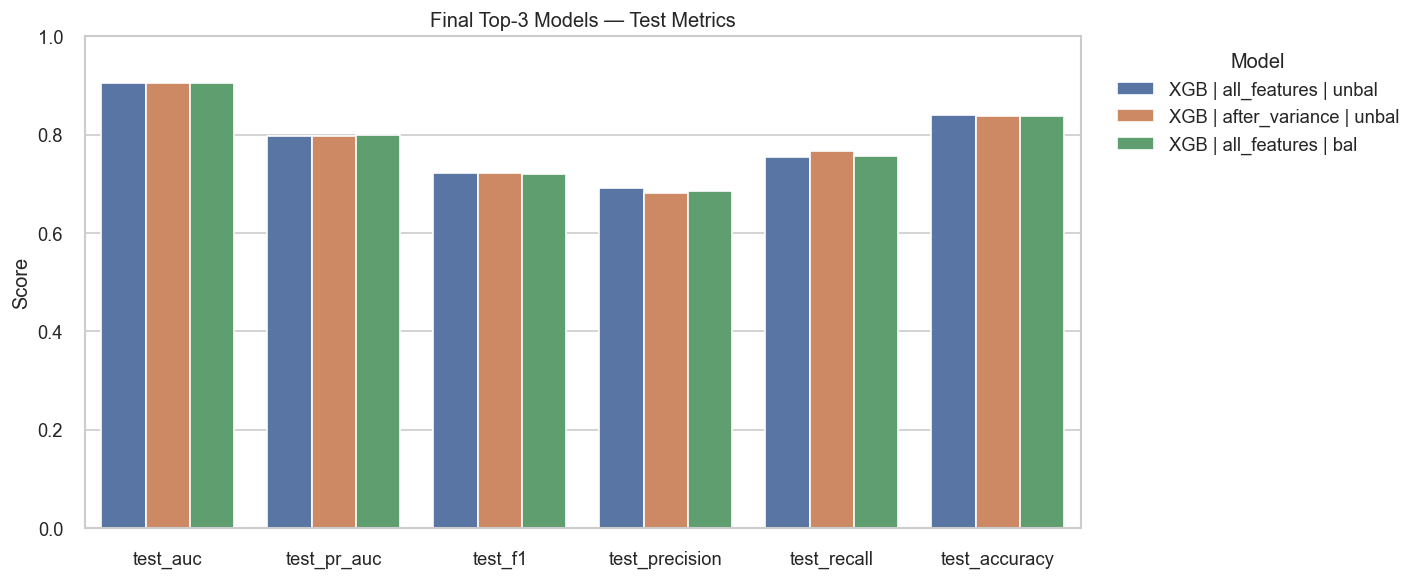

In [53]:
# Pick top 3 by test AUC
final3 = enhanced_test_df.sort_values("test_auc", ascending=False).head(3).copy()
display(final3)

# bar chart of test metrics
metrics_long = final3.melt(
    id_vars=["model_name", "feature_set", "balanced"],
    value_vars=["test_auc", "test_pr_auc", "test_f1", "test_precision", "test_recall", "test_accuracy"],
    var_name="metric",
    value_name="score"
)
metrics_long["label"] = (
    metrics_long["model_name"] + " | " +
    metrics_long["feature_set"] + " | " +
    metrics_long["balanced"].map({True: "bal", False: "unbal"})
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=metrics_long, x="metric", y="score", hue="label", ax=ax)
ax.set_title("Final Top-3 Models — Test Metrics")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("modeling_visuals/final_top3/01_top3_test_metrics.png", bbox_inches="tight")
plt.show()

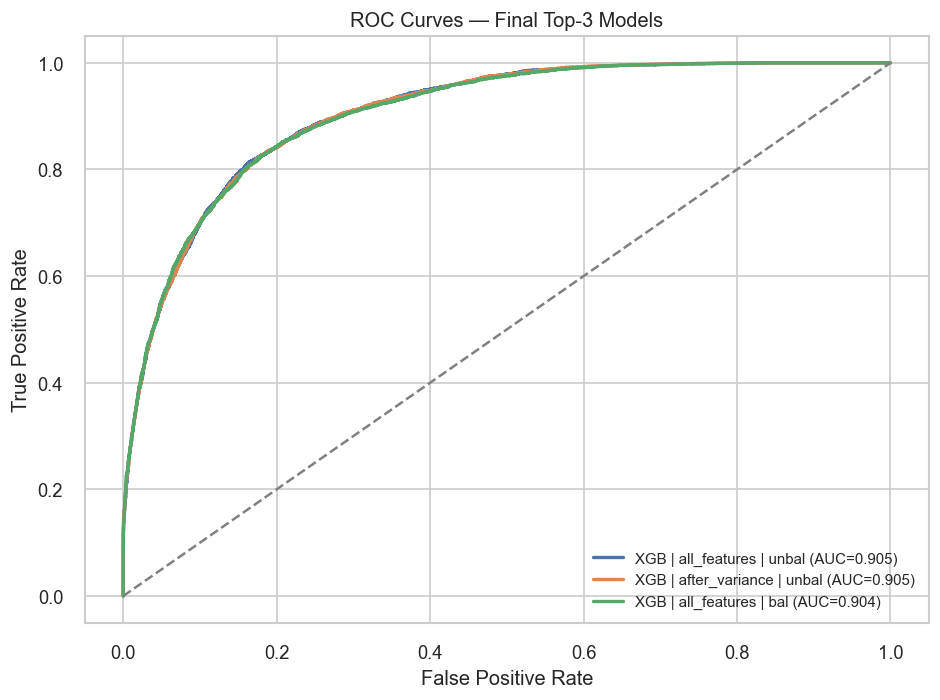

In [57]:
# ROC curves (overlay)
fig, ax = plt.subplots(figsize=(8, 6))
for _, row in final3.iterrows():
    model_name = row["model_name"]
    fs_name = row["feature_set"]
    use_smote = bool(row["balanced"])
    source = row["source"]
    key = f"{model_name}_{fs_name}_{'bal' if use_smote else 'unbal'}_{source}"

    est = enhanced_saved_estimators[key]
    cols = feature_sets[fs_name]
    Xte = X_test[cols]

    y_proba = est.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    label = f"{model_name} | {fs_name} | {'bal' if use_smote else 'unbal'} (AUC={roc_auc:.3f})"
    ax.plot(fpr, tpr, lw=2, label=label)

ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_title("ROC Curves — Final Top-3 Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("modeling_visuals/final_top3/02_top3_roc_curves.png", bbox_inches="tight")
plt.show()

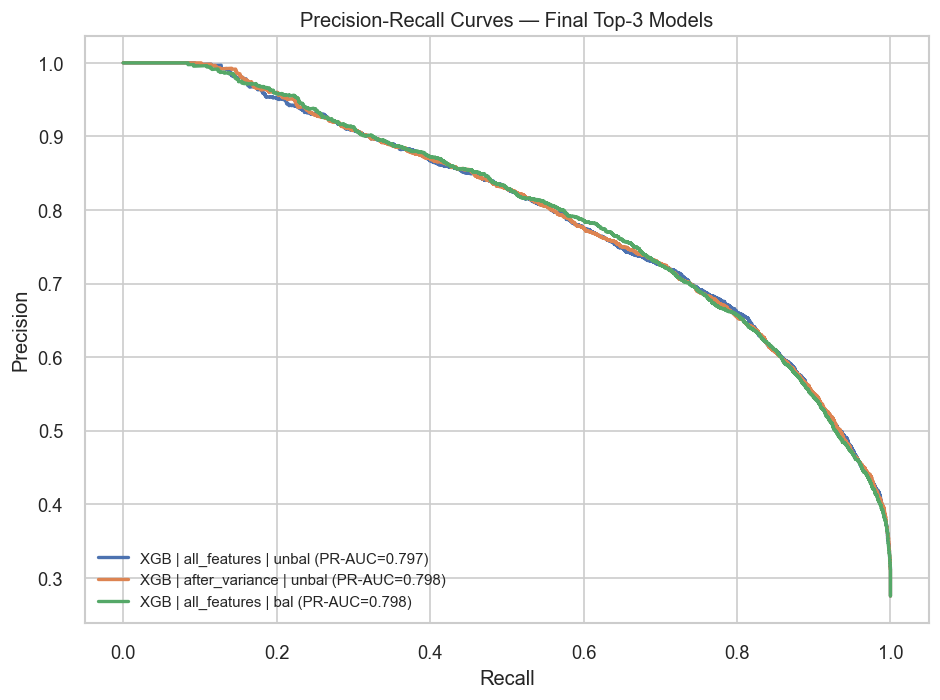

In [58]:
# Precision-Recall curves (overlay)
fig, ax = plt.subplots(figsize=(8, 6))
for _, row in final3.iterrows():
    model_name = row["model_name"]
    fs_name = row["feature_set"]
    use_smote = bool(row["balanced"])
    key = f"{model_name}_{fs_name}_{'bal' if use_smote else 'unbal'}_{row['source']}"

    est = enhanced_saved_estimators[key]
    cols = feature_sets[fs_name]
    Xte = X_test[cols]

    y_proba = est.predict_proba(Xte)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    label = f"{model_name} | {fs_name} | {'bal' if use_smote else 'unbal'} (PR-AUC={pr_auc:.3f})"
    ax.plot(recall, precision, lw=2, label=label)

ax.set_title("Precision-Recall Curves — Final Top-3 Models")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.savefig("modeling_visuals/final_top3/03_top3_pr_curves.png", bbox_inches="tight")
plt.show()

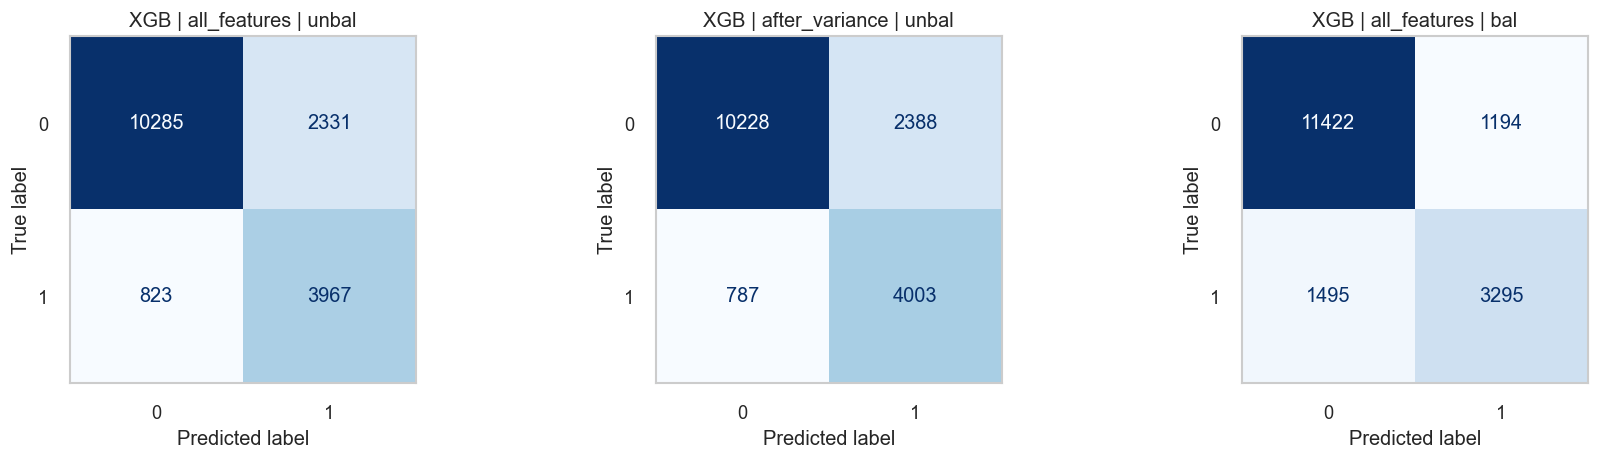

In [60]:
import matplotlib.ticker as mticker

# Confusion matrices (threshold=0.5)
n = len(final3)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, final3.iterrows()):
    model_name = row["model_name"]
    fs_name = row["feature_set"]
    use_smote = bool(row["balanced"])
    key = f"{model_name}_{fs_name}_{'bal' if use_smote else 'unbal'}_{row['source']}"

    est = enhanced_saved_estimators[key]
    cols = feature_sets[fs_name]
    Xte = X_test[cols]

    y_pred = est.predict(Xte)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, cmap="Blues", colorbar=False, values_format="d"
    )
    ax.set_title(f"{model_name} | {fs_name} | {'bal' if use_smote else 'unbal'}")

    # disable grid
    ax.grid(False)

    # force full integer tick labels (no scientific notation)
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.0f}'))

plt.tight_layout()
plt.savefig("modeling_visuals/final_top3/04_top3_confusion_matrices.png", bbox_inches="tight")
plt.show()


The model with the lowest false negative is the xgb, after variance unbalanced, it also has the highest recall and f1 (important for business to catch as many cancellations as possible). Other metrics are similar so this one wins

#### Saving all models

In [49]:
# saving all the models in case the notebook restarts...

# Save all trained model objects with clear names + metadata
import os
import re
import json
import joblib
from datetime import datetime

os.makedirs("models", exist_ok=True)

def slug(s):
    return re.sub(r"[^a-zA-Z0-9_\\-]+", "_", str(s)).strip("_").lower()

saved_index = []

# 1) Save enhanced manual models (from test-eval stage)
# expected: enhanced_saved_estimators dict exists
if "enhanced_saved_estimators" in globals() and len(enhanced_saved_estimators) > 0:
    for key, est in enhanced_saved_estimators.items():
        # key format from your code:
        # "{model_name}_{feature_set}_{bal/unbal}_{source}"
        fname = f"model__{slug(key)}.pkl"
        path = os.path.join("models", fname)
        joblib.dump(est, path)

        saved_index.append({
            "artifact_type": "trained_model",
            "save_key": key,
            "file": path
        })

# 2) Save AutoML candidate models (tuned/blend/stack) if you want all of them too
# expected: automl_models dict exists
if "automl_models" in globals() and len(automl_models) > 0:
    for key, est in automl_models.items():
        # key format: tuned_1__after_variance__bal, blend__..., stack__...
        fname = f"pycaret__{slug(key)}.pkl"
        path = os.path.join("models", fname)
        joblib.dump(est, path)

        saved_index.append({
            "artifact_type": "pycaret_model",
            "save_key": key,
            "file": path
        })

# 3) Save XGB tuned estimators + thresholds
# expected: xgb_enhanced_estimators dict with {'estimator':..., 'threshold':...}
xgb_thresholds = {}
if "xgb_enhanced_estimators" in globals() and len(xgb_enhanced_estimators) > 0:
    for key, obj in xgb_enhanced_estimators.items():
        est = obj["estimator"] if isinstance(obj, dict) and "estimator" in obj else obj
        thr = obj.get("threshold", 0.5) if isinstance(obj, dict) else 0.5

        fname = f"xgb_tuned__{slug(key)}.pkl"
        path = os.path.join("models", fname)
        joblib.dump(est, path)

        xgb_thresholds[key] = float(thr)
        saved_index.append({
            "artifact_type": "xgb_tuned_model",
            "save_key": key,
            "file": path,
            "threshold": float(thr)
        })

if xgb_thresholds:
    with open("models/xgb_thresholds.json", "w", encoding="utf-8") as f:
        json.dump(xgb_thresholds, f, indent=2)

# 4) Save selector/encoder/feature metadata if available
meta = {
    "saved_at": datetime.now().isoformat(),
    "target": TARGET if "TARGET" in globals() else "is_canceled",
    "n_saved_artifacts": len(saved_index),
    "artifacts": saved_index
}

if "feature_sets" in globals():
    meta["feature_sets"] = feature_sets

if "comparison_df" in globals():
    meta["top_cv_rows"] = comparison_df.head(10).to_dict(orient="records")

if "enhanced_test_df" in globals():
    meta["top_test_rows"] = enhanced_test_df.head(10).to_dict(orient="records")

with open("models/model_registry.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print(f"Saved {len(saved_index)} model artifacts.")
print("Registry: models/model_registry.json")
if xgb_thresholds:
    print("XGB thresholds: models/xgb_thresholds.json")


Saved 33 model artifacts.
Registry: models/model_registry.json
XGB thresholds: models/xgb_thresholds.json


In [63]:
display(final3.iloc[1])

model_name                   XGB
feature_set       after_variance
balanced                   False
source                       xgb
threshold                    0.6
test_accuracy            0.83678
test_auc                0.905068
test_pr_auc             0.797624
test_f1                 0.721279
test_precision          0.680363
test_recall             0.767432
Name: 1, dtype: object

In [64]:
# save best model explicitly

# best row
best_row = final3.iloc[1]

best_model_name = best_row["model_name"]
best_feature_set = best_row["feature_set"]
best_balanced = bool(best_row["balanced"])
best_source = best_row["source"]
best_threshold = float(best_row.get("threshold"))

best_key = f"{best_model_name}_{best_feature_set}_{'bal' if best_balanced else 'unbal'}_{best_source}"

if best_key not in enhanced_saved_estimators:
    raise KeyError(f"Best model key not found in enhanced_saved_estimators: {best_key}")

best_estimator = enhanced_saved_estimators[best_key]

# save model artifact
best_model_path = "models/best/best_model.pkl"
joblib.dump(best_estimator, best_model_path)

# save config/metadata for loading + inference
best_model_meta = {
    "saved_at": datetime.now().isoformat(),
    "best_model_key": best_key,
    "model_name": best_model_name,
    "feature_set": best_feature_set,
    "balanced": best_balanced,
    "source": best_source,
    "threshold": best_threshold,
    "target": TARGET,
    "metrics": {
        "test_accuracy": float(best_row.get("test_accuracy", float("nan"))),
        "test_auc": float(best_row.get("test_auc", float("nan"))),
        "test_pr_auc": float(best_row.get("test_pr_auc", float("nan"))),
        "test_f1": float(best_row.get("test_f1", float("nan"))),
        "test_precision": float(best_row.get("test_precision", float("nan"))),
        "test_recall": float(best_row.get("test_recall", float("nan")))
    }
}
with open("models/best/best_model_meta.json", "w", encoding="utf-8") as f:
    json.dump(best_model_meta, f, indent=2)

print("Saved best model:", best_model_path)
print("Saved best model metadata: models/best/best_model_meta.json")
print("Best model key:", best_key)


Saved best model: models/best/best_model.pkl
Saved best model metadata: models/best/best_model_meta.json
Best model key: XGB_after_variance_unbal_xgb


### Retraining and packaging best model

In [32]:
# load best saved model + metadata, then retrain on full data and save to models/final
import os

best_model_path = "models/best/best_model.pkl"
best_meta_path = "models/best/best_model_meta.json"

best_estimator_loaded = joblib.load(best_model_path)
with open(best_meta_path, "r", encoding="utf-8") as f:
    best_model_meta = json.load(f)

best_feature_set = best_model_meta["feature_set"]
best_balanced = bool(best_model_meta.get("balanced", False))
best_model_name = best_model_meta.get("model_name", "model")
best_source = best_model_meta.get("source", "unknown")
best_cols = feature_sets[best_feature_set]

X_full = pd.concat([X_train, X_test], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)
Xf = X_full[best_cols]

# clone keeps tuned hyperparameters while resetting fitted state
try:
    final_estimator = clone(best_estimator_loaded)
except Exception:
    import copy
    final_estimator = copy.deepcopy(best_estimator_loaded)

final_estimator.fit(Xf, y_full)

os.makedirs("models/final", exist_ok=True)
final_model_path = "models/final/final_model.pkl"
joblib.dump(final_estimator, final_model_path)

final_tag = f"{best_model_name}_{best_feature_set}_{'bal' if best_balanced else 'unbal'}_{best_source}"
print("Loaded best model from:", best_model_path)
print("Retrained on full data with feature set:", best_feature_set)
print("Saved:", final_model_path)


Loaded best model from: models/best/best_model.pkl
Retrained on full data with feature set: after_variance
Saved: models/final/final_model.pkl


In [33]:
# save final model metadata
final_meta = {
    "saved_at": datetime.now().isoformat(),
    "target": TARGET,
    "final_model_path": final_model_path,
    "final_model_tag": final_tag,
    "model_name": best_model_name,
    "feature_set": best_feature_set,
    "balanced": best_balanced,
    "source": best_source,
    "best_model_path": best_model_path,
    "best_model_meta_path": best_meta_path,
    "best_model_meta": best_model_meta,
    "feature_sets": {
        best_feature_set: feature_sets[best_feature_set]
    }
}

final_meta_path = "models/final/final_model_meta.json"
with open(final_meta_path, "w", encoding="utf-8") as f:
    json.dump(final_meta, f, indent=2)

# encoder already saved earlier as models/ordinal_encoder.pkl
print("Saved:", final_meta_path)


Saved: models/final/final_model_meta.json
